In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class HeatConductionCN:
    def __init__(self, alpha=2.3e-5, L=1.0, dx=0.01, dt=0.005, tol=1e-4):
        self.alpha = alpha
        self.L = L
        self.dx = dx
        self.N = round(L / dx)
        self.dt = dt
        self.tol = tol

        # spatial grid
        self.x = np.linspace(0, L, self.N + 1)

        # Initial & boundary conditions
        self.T = np.full(self.N + 1, 30.0)
        self.T[0] = 0.0
        self.T[-1] = 100.0

        self.snapshots = [self.T.copy()]
        self.times = [0.0]
        self.iterations = 0
        self.t = 0.0

        # CN coefficient
        self.r = self.alpha * self.dt / (self.dx ** 2)

        # Construct CN matrices (interior nodes only)
        main_A = (1 + self.r) * np.ones(self.N - 1)
        off_A = -self.r / 2 * np.ones(self.N - 2)
        self.A = np.diag(main_A) + np.diag(off_A, 1) + np.diag(off_A, -1)

        main_B = (1 - self.r) * np.ones(self.N - 1)
        off_B = self.r / 2 * np.ones(self.N - 2)
        self.B = np.diag(main_B) + np.diag(off_B, 1) + np.diag(off_B, -1)

    def run(self):
        while True:
            self.iterations += 1

            # RHS: B*T^n (interior only)
            b = self.B @ self.T[1:self.N]

            # Apply boundary conditions
            b[0] += (self.r / 2) * (self.T[0] + self.T[0])
            b[-1] += (self.r / 2) * (self.T[-1] + self.T[-1])

            # Solve system
            T_new = self.T.copy()
            T_new[1:self.N] = np.linalg.solve(self.A, b)

            # Convergence check
            max_change = np.max(np.abs(T_new - self.T))
            self.T = T_new
            self.t += self.dt

            if self.iterations % 100 == 0:
                self.snapshots.append(self.T.copy())
                self.times.append(self.t)
                print(f"Iteration {self.iterations}: time = {self.t:.2f} s, max_change = {max_change:.6f}")

            if max_change < self.tol:
                self.snapshots.append(self.T.copy())
                self.times.append(self.t)
                break

        print(f"Simulation converged after {self.iterations} iterations")
        print(f"Final simulation time: {self.t:.2f} seconds")

    def plot_snapshots(self, num_plots=7):
        indices = np.round(np.linspace(0, len(self.times) - 1, num_plots)).astype(int)

        plt.figure()
        for idx in indices:
            plt.plot(self.x, self.snapshots[idx], label=f"t = {self.times[idx]:.2f} s")
        plt.xlabel("Position x (m)")
        plt.ylabel("Temperature (°C)")
        plt.title("Heat Conduction in Iron Rod (Crank–Nicolson)")
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_final_distribution(self):
        probe_indices = np.arange(0, self.N + 1, 10)
        final_idx = -1

        plt.figure()
        plt.plot(self.x, self.snapshots[final_idx], 'r', linewidth=1.5,
                 label=f"Final t = {self.times[final_idx]:.2f} s")
        plt.scatter(self.x[probe_indices], self.snapshots[final_idx][probe_indices],
                    c='k', s=50, label="Probe points")
        plt.xlabel("Position x (m)")
        plt.ylabel("Temperature (°C)")
        plt.title("Final Temperature Distribution at 10 points")
        plt.legend()
        plt.grid(True)
        plt.show()

Iteration 100: time = 0.50 s, max_change = 0.064454
Iteration 200: time = 1.00 s, max_change = 0.052228
Iteration 300: time = 1.50 s, max_change = 0.042869
Iteration 400: time = 2.00 s, max_change = 0.035629
Iteration 500: time = 2.50 s, max_change = 0.029967
Iteration 600: time = 3.00 s, max_change = 0.025491
Iteration 700: time = 3.50 s, max_change = 0.021915
Iteration 800: time = 4.00 s, max_change = 0.019028
Iteration 900: time = 4.50 s, max_change = 0.016672
Iteration 1000: time = 5.00 s, max_change = 0.014731
Iteration 1100: time = 5.50 s, max_change = 0.013407
Iteration 1200: time = 6.00 s, max_change = 0.012707
Iteration 1300: time = 6.50 s, max_change = 0.012030
Iteration 1400: time = 7.00 s, max_change = 0.011385
Iteration 1500: time = 7.50 s, max_change = 0.010776
Iteration 1600: time = 8.00 s, max_change = 0.010205
Iteration 1700: time = 8.50 s, max_change = 0.009671
Iteration 1800: time = 9.00 s, max_change = 0.009172
Iteration 1900: time = 9.50 s, max_change = 0.008709
It

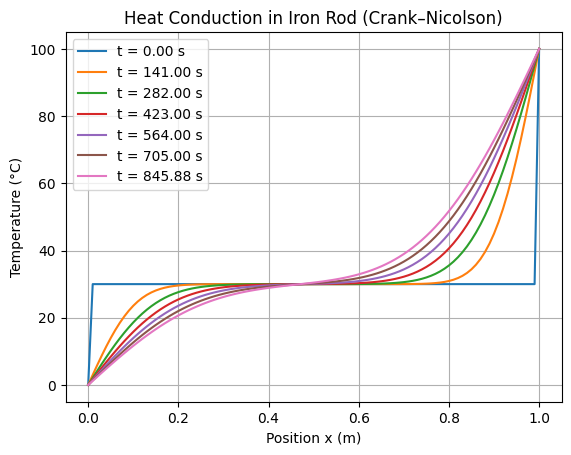

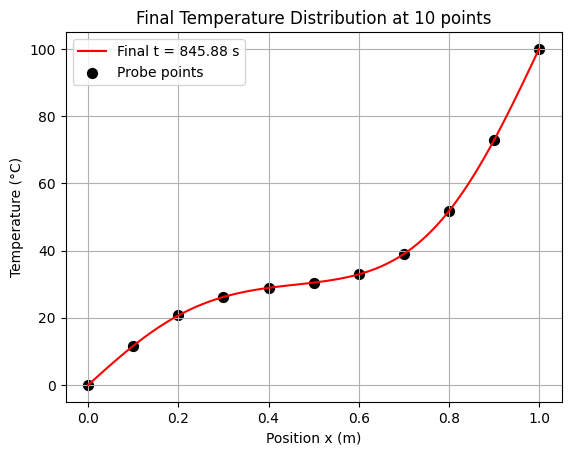

In [3]:
    sim = HeatConductionCN()
    sim.run()
    sim.plot_snapshots()
    sim.plot_final_distribution()